<a href="https://colab.research.google.com/github/tri-tt-hik/ML_LAB/blob/main/VLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q transformers accelerate torch torchvision pillow
!pip install -q qwen-vl-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 25.2 MB/s eta 0:00:00


In [ ]:
from transformers import Qwen2_5_VLForConditionalGeneration
from transformers import AutoProcessor
from PIL import Image
import torch
import json

In [ ]:
model_name = "Qwen/Qwen2.5-VL-3B-Instruct"

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

processor = AutoProcessor.from_pretrained(model_name)

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

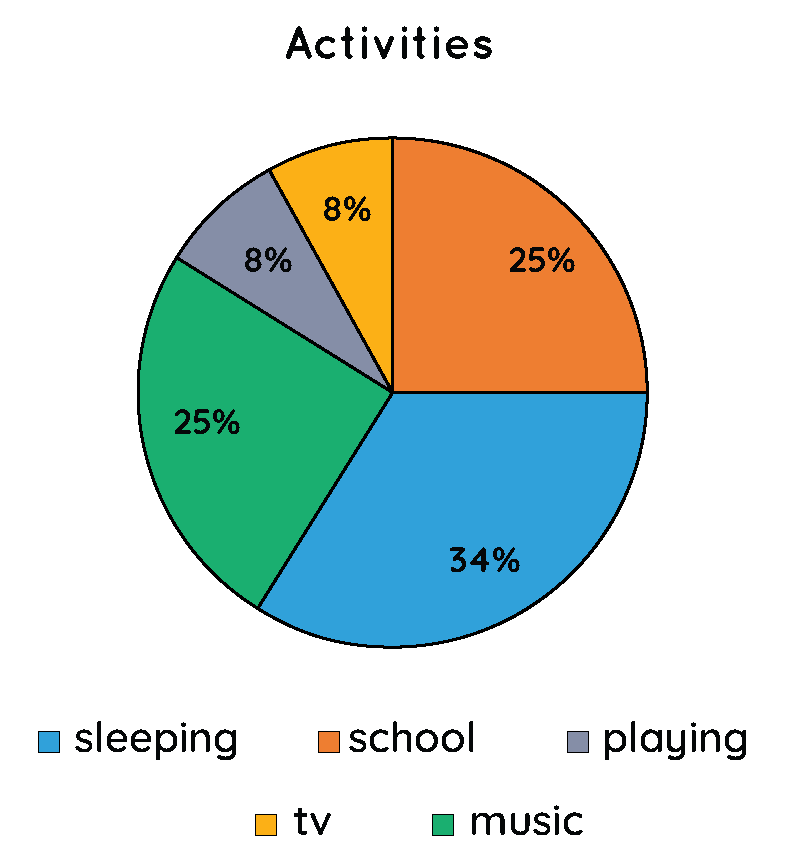

In [ ]:
image_path = "/content/chart.png"

image = Image.open(image_path)
image

In [ ]:
prompt = """
Analyze this image carefully.

Extract:
1. Main subject
2. Important text
3. Trends or patterns
4. Key insights
5. Anomalies
6. Summary

Return the output in JSON format.
"""

In [ ]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": image
            },
            {
                "type": "text",
                "text": prompt
            }
        ]
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

In [ ]:
inputs = processor(
    text=[text],
    images=[image],
    padding=True,
    return_tensors="pt"
).to("cuda")

In [ ]:
generated_ids = model.generate(
    **inputs,
    max_new_tokens=512
)

In [ ]:
output_text = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print(output_text)

system
You are a helpful assistant.
user

Analyze this image carefully.

Extract:
1. Main subject
2. Important text
3. Trends or patterns
4. Key insights
5. Anomalies
6. Summary

Return the output in JSON format.

assistant
```json
{
  "main_subject": "Pie chart displaying time allocation for different activities",
  "important_text": {
    "sleeping": "34%",
    "school": "25%",
    "playing": "8%",
    "tv": "8%",
    "music": "25%"
  },
  "trends_or_patterns": {
    "most common activity": "sleeping",
    "equal distribution": ["school", "music"],
    "least common activities": ["playing", "tv"]
  },
  "key_insights": {
    "majority of time is spent sleeping",
    "time spent on school and music is equal",
    "playing and TV have the same percentage of time"
  },
  "anomalies": {
    "no significant anomalies detected"
  },
  "summary": "The pie chart shows that the majority of time is spent sleeping, with an equal distribution of time spent on school and music. Playing and TV eac

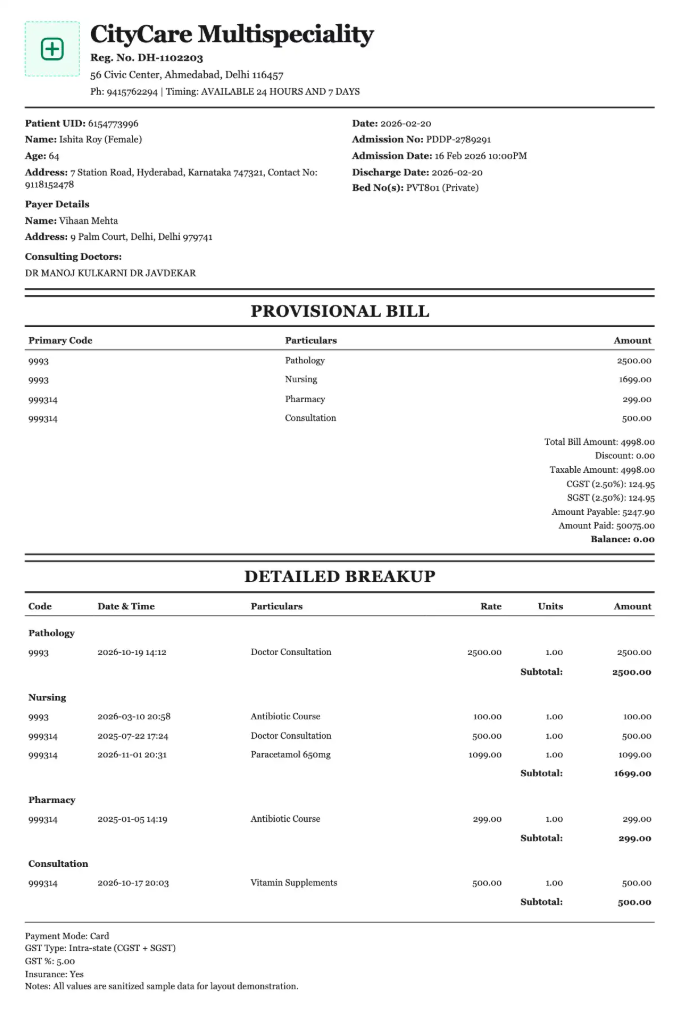

In [ ]:
bill_image_path = "/content/bill.png"

bill_image = Image.open(bill_image_path)
bill_image

In [30]:
EXTRACTION_PROMPT = """
You are an intelligent medical document extraction system.

Analyze this medical bill carefully.

Extract:
- patient details
- hospital details
- medicines from DETAILED BREAKUP
- billing summary
- billed services

RULES:
- Return ONLY ONE valid JSON object
- Do NOT explain
- Do NOT include markdown
- Do NOT repeat instructions
- Do NOT repeat schema
- Missing fields should be null

Required JSON fields:
patient_details
hospital_details
bill_items
medicines
billing_summary
billed_services
"""

In [31]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": bill_image
            },
            {
                "type": "text",
                "text": EXTRACTION_PROMPT
            }
        ]
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = processor(
    text=[text],
    images=[bill_image],
    padding=True,
    return_tensors="pt"
).to("cuda")

generated_ids = model.generate(
    **inputs,
    max_new_tokens=2048,
    do_sample=False,
    eos_token_id=processor.tokenizer.eos_token_id
)

output_text = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print(output_text)

system
You are a helpful assistant.
user

You are an intelligent medical document extraction system.

Analyze this medical bill carefully.

Extract:
- patient details
- hospital details
- medicines from DETAILED BREAKUP
- billing summary
- billed services

RULES:
- Return ONLY ONE valid JSON object
- Do NOT explain
- Do NOT include markdown
- Do NOT repeat instructions
- Do NOT repeat schema
- Missing fields should be null

Required JSON fields:
patient_details
hospital_details
bill_items
medicines
billing_summary
billed_services

assistant
```json
{
  "patient_details": {
    "patient_id": "6154773996",
    "name": "Ishita Roy (Female)",
    "age": 64,
    "address": "7 Station Road, Hyderabad, Karnataka 747321",
    "contact_number": "918152478"
  },
  "hospital_details": {
    "hospital_name": "CityCare Multispeciality",
    "registration_number": "DH-1102203",
    "location": "56 Civic Center, Ahmedabad, Delhi 116457",
    "phone_number": "9415762294",
    "timing": "Available 24 h

In [32]:
import re
import json
import json

def extract_json(text):

    # Remove markdown wrappers
    text = text.replace("```json", "")
    text = text.replace("```", "")

    # Find JSON boundaries
    start = text.find("{")
    end = text.rfind("}")

    if start == -1 or end == -1:
        print("No JSON found")
        return None

    json_text = text[start:end + 1]

    try:
        parsed = json.loads(json_text)
        return parsed

    except json.JSONDecodeError as e:
        print("JSON Decode Error:")
        print(e)

        print("\nProblematic JSON:\n")
        print(json_text)

        return None

structured_output = extract_json(output_text)

print(json.dumps(structured_output, indent=4))

{
    "patient_details": {
        "patient_id": "6154773996",
        "name": "Ishita Roy (Female)",
        "age": 64,
        "address": "7 Station Road, Hyderabad, Karnataka 747321",
        "contact_number": "918152478"
    },
    "hospital_details": {
        "hospital_name": "CityCare Multispeciality",
        "registration_number": "DH-1102203",
        "location": "56 Civic Center, Ahmedabad, Delhi 116457",
        "phone_number": "9415762294",
        "timing": "Available 24 hours and 7 days"
    },
    "bill_items": [
        {
            "code": "9993",
            "date_time": "2026-02-20 10:00:00",
            "particulars": "Pathology",
            "rate": 2500.0,
            "units": 1,
            "amount": 2500.0
        },
        {
            "code": "9993",
            "date_time": "2026-02-20 10:00:00",
            "particulars": "Nursing",
            "rate": 1699.0,
            "units": 1,
            "amount": 1699.0
        },
        {
            "code": "

In [33]:
print(structured_output["patient_details"])

{'patient_id': '6154773996', 'name': 'Ishita Roy (Female)', 'age': 64, 'address': '7 Station Road, Hyderabad, Karnataka 747321', 'contact_number': '918152478'}
